In [1]:
import pandas as pd
import numpy as np
import torch
import pickle
import os
from tqdm import tqdm
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tueplots import bundles
bundles.icml2024()

from torchmetrics import AUROC
auroc = AUROC(task="binary")

import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(0)

device = "cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

def visualize_response_matrix(results, value, filename):
    # Extract the groups labels in the order of the columns
    group_values = results.columns.get_level_values("scenario")

    # Identify the boundaries where the group changes
    boundaries = []
    for i in range(1, len(group_values)):
        if group_values[i] != group_values[i - 1]:
            boundaries.append(i - 0.5)  # using 0.5 to place the line between columns

    # Visualize the results with a matrix: red is 0, white is -1 and blue is 1
    cmap = mcolors.ListedColormap(["white", "red", "blue"])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Calculate midpoints for each group label
    groups_list = list(group_values)
    group_names = []
    group_midpoints = []
    current_group = groups_list[0]
    start_index = 0
    for i, grp in enumerate(groups_list):
        if grp != current_group:
            midpoint = (start_index + i - 1) / 2.0
            group_names.append(current_group)
            group_midpoints.append(midpoint)
            current_group = grp
            start_index = i
    # Add the last group
    midpoint = (start_index + len(groups_list) - 1) / 2.0
    group_names.append(current_group)
    group_midpoints.append(midpoint)

    # Define the minimum spacing between labels (e.g., 100 units)
    min_spacing = 100
    last_label_pos = -float("inf")
    # Plot the matrix
    with plt.rc_context(bundles.icml2024(usetex=True, family="serif")):
        fig, ax = plt.subplots(figsize=(20, 10))
        cax = ax.matshow(value, aspect="auto", cmap=cmap, norm=norm)

        # Add vertical lines at each boundary
        for b in boundaries:
            ax.axvline(x=b, color="black", linewidth=0.25, linestyle="--", alpha=0.5)
        
        # Add group labels above the matrix, only if they're spaced enough apart
        for name, pos in zip(group_names, group_midpoints):
            if pos - last_label_pos >= min_spacing:
                ax.text(pos, -5, name, ha='center', va='bottom', rotation=90, fontsize=3)
                last_label_pos = pos

        # Add model labels on the y-axis
        ax.set_yticks(range(len(results.index)))
        ax.set_yticklabels(results.index, fontsize=3)

        # Add a colorbar
        cbar = plt.colorbar(cax)
        cbar.set_ticks([-1, 0, 1])
        cbar.set_ticklabels(["-1", "0", "1"])
        plt.savefig(filename, dpi=600, bbox_inches="tight")
        plt.close()

def trainer(parameters, optim, closure, n_iter=100, verbose=True):
    pbar = tqdm(range(n_iter)) if verbose else range(n_iter)
    for iteration in pbar:
        if iteration > 0:
            previous_parameters = [p.clone() for p in parameters]
            previous_loss = loss.clone()
        
        loss = optim.step(closure)
        
        if iteration > 0:
            d_loss = (previous_loss - loss).item()
            d_parameters = sum(
                torch.norm(prev - curr, p=2).item()
                for prev, curr in zip(previous_parameters, parameters)
            )
            grad_norm = sum(torch.norm(p.grad, p=2).item() for p in parameters if p.grad is not None)
            if verbose:
                pbar.set_postfix({"grad_norm": grad_norm, "d_parameter": d_parameters, "d_loss": d_loss})
            
            if d_loss < 1e-5 and d_parameters < 1e-5 and grad_norm < 1e-5:
                break
    return parameters

def compute_auc(probs, data, train_idtor, test_idtor):
    train_probs = probs[train_idtor.bool()]
    test_probs = probs[test_idtor.bool()]
    train_labels = data[train_idtor.bool()]
    test_labels = data[test_idtor.bool()]
    train_auc = auroc(train_probs, train_labels)
    test_auc = auroc(test_probs, test_labels)
    print(f"train auc: {train_auc}")
    print(f"test auc: {test_auc}")
    
    return train_auc, test_auc

def compute_cttcorr(probs, data, train_idtor, test_idtor):
    train_probs  = probs.clone()
    test_probs   = probs.clone()
    train_labels = data.clone()
    test_labels  = data.clone()

    train_mask = ~train_idtor.bool()
    train_probs[train_mask]  = float('nan')
    train_labels[train_mask] = float('nan')

    test_mask = ~test_idtor.bool()
    test_probs[test_mask]   = float('nan')
    test_labels[test_mask]  = float('nan')
    
    train_prob_ctt = torch.nanmean(train_probs, dim=1).detach().cpu().numpy()
    train_label_ctt = torch.nanmean(train_labels, dim=1).detach().cpu().numpy()
    train_mask = ~np.isnan(train_prob_ctt) & ~np.isnan(train_label_ctt)
    train_cttcorr = pearsonr(train_prob_ctt[train_mask], train_label_ctt[train_mask]).statistic
    
    test_prob_ctt = torch.nanmean(test_probs, dim=1).detach().cpu().numpy()
    test_label_ctt = torch.nanmean(test_labels, dim=1).detach().cpu().numpy()
    test_mask = ~np.isnan(test_prob_ctt) & ~np.isnan(test_label_ctt)
    test_cttcorr = pearsonr(test_prob_ctt[test_mask], test_label_ctt[test_mask]).statistic
    
    print(f"train cttcorr: {train_cttcorr}")
    print(f"test cttcorr: {test_cttcorr}")

    return train_cttcorr, test_cttcorr

In [2]:
# Fixed evaluation to match training data preprocessing and split
import pickle
import numpy as np
import pandas as pd
from scipy.special import expit
import torch
import sys
sys.path.append('../mirt-official')
from load_params import load_and_rotate

# Load original resmat
with open('../data/resmat.pkl', 'rb') as f:
    resmat = pickle.load(f)

print(f"Original resmat shape: {resmat.shape}")
print(f"NaN values: {resmat.isna().sum().sum()}")

# CRITICAL FIX: Match k-trials-rep.py preprocessing
# Fill ALL NaN values with 0 (same as training)
resmat_filled = resmat.fillna(0)
print(f"After filling NaNs with 0: {resmat_filled.isna().sum().sum()} NaN values remain")

# CRITICAL FIX: Match k-trials-rep.py train/test split
# For rep2, the seed used was repetition=1 (0-indexed, so repetition 1 = rep2)
seed = 1  # This matches the seed used for rep2 in k-trials-rep.py
np.random.seed(seed)

# Create observed pairs the same way as k-trials-rep.py
# Since we filled NaNs with 0, ALL positions are now "observed"
observed_pairs = np.argwhere(~resmat_filled.isna().values)  # This will be ALL positions
print(f"Total observed pairs: {len(observed_pairs)}")

# Shuffle and split the same way as training
np.random.shuffle(observed_pairs)

test_frac = 0.20
n_test = int(len(observed_pairs) * test_frac)
test_pairs = observed_pairs[:n_test]
train_pairs = observed_pairs[n_test:]

test_indices = test_pairs
train_indices = train_pairs

print(f"Split data into {len(train_indices)} train samples and {len(test_indices)} test samples.")


Original resmat shape: (183, 78712)
NaN values: 9069522
NaN values: 9069522
After filling NaNs with 0: 0 NaN values remain
After filling NaNs with 0: 0 NaN values remain
Total observed pairs: 14404296
Split data into 11523437 train samples and 2880859 test samples.
Total observed pairs: 14404296
Split data into 11523437 train samples and 2880859 test samples.


In [3]:
# ===================================================================
# == Step 2: Load MIRT Model Parameters (rep2)
# ===================================================================
print(f"\nLoading MIRT model parameters from rep2...")

# Load and rotate MIRT parameters using load_params.py
theta_z_scores, a_rotated, b_adjusted = load_and_rotate('../mirt-official/output/mirt_model_k19_rep2.pt', rotation=None)

print(f"Loaded MIRT model with {theta_z_scores.shape[1]} factors")
print(f"Subject abilities (theta) shape: {theta_z_scores.shape}")
print(f"Item parameters (a) shape: {a_rotated.shape}")
print(f"Item difficulties (b) shape: {b_adjusted.shape}")

# Use MIRT parameters instead of SVD
subject_scores = theta_z_scores  # Use rotated and standardized theta
all_item_factors_T = a_rotated.T  # Transpose for compatibility with downstream code

# Reconstruct the full matrix using MIRT 2PL model
# logits = theta @ a.T - b
reconstructed_matrix = subject_scores @ all_item_factors_T - b_adjusted[None, :]
probs_matrix_np = expit(reconstructed_matrix)

print(f"Successfully reconstructed the full matrix of shape: {reconstructed_matrix.shape}")

# ===================================================================
# == Step 3: Prepare Data for Evaluation (FIXED to match training)
# ===================================================================
# Use the filled data (same as training)
data_np = resmat_filled.values  # Use filled data, not fillna(0) at evaluation time

# Create boolean masks (numpy)
train_idtor_np = np.zeros_like(data_np, dtype=bool)
test_idtor_np = np.zeros_like(data_np, dtype=bool)
train_idtor_np[train_indices[:, 0], train_indices[:, 1]] = True
test_idtor_np[test_indices[:, 0], test_indices[:, 1]] = True

# Convert NumPy arrays to PyTorch tensors for evaluation
print("\nConverting results to PyTorch Tensors for evaluation...")
device = "cuda:0" if torch.cuda.is_available() else "cpu"

probs_tensor = torch.tensor(probs_matrix_np, dtype=torch.float32, device=device)
data_tensor = torch.tensor(data_np, dtype=torch.float32, device=device)
train_idtor_tensor = torch.tensor(train_idtor_np, dtype=torch.int, device=device)
test_idtor_tensor = torch.tensor(test_idtor_np, dtype=torch.int, device=device)

print("\n--- Running CORRECTED MIRT Model Evaluation (matching training setup) ---")
compute_auc(probs_tensor, data_tensor, train_idtor_tensor, test_idtor_tensor)
compute_cttcorr(probs_tensor, data_tensor, train_idtor_tensor, test_idtor_tensor)



Loading MIRT model parameters from rep2...
--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)

Loaded MIRT model with 19 factors
Subject abilities (theta) shape: (183, 19)
Item parameters (a) shape: (78712, 19)
Item difficulties (b) shape: (78712,)
Successfully reconstructed the full matrix of shape: (183, 78712)
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)

Loaded MIRT model with 19 factors
Subject abilities (theta) shape: (183, 19)
Item parameters (a) shape: (78712, 19)
Item difficulties (b) shape: (78712,)
Successfully reconstructed the full matrix of shape: (183, 78712)

Converting results to PyTorch Tensors for evaluation...

Converting results to PyTorch Tensors for evaluation...

--- Running CORRECTED MIRT Model Evaluation (matching training setup) ---

--- Running CORRECTED MIRT Model Evaluation (matching training setup) ---
train auc: 0.98

(np.float32(0.9998244), np.float32(0.99976504))

In [4]:
with open("../data/embed_meta-llama_Llama-3.1-8B-Instruct.pkl", "rb") as f:
    df_embed = pickle.load(f)

In [5]:
# ===================================================================
# == Step 3: Prepare NN Training Data with MIRT Parameters (a + b)
# ===================================================================

question_to_emb = dict(zip(df_embed["question"], df_embed["embedding"]))
questions = resmat.columns.get_level_values("input.text").tolist()
embeds = [question_to_emb.get(q, None) for q in questions]

# Combine discrimination parameters (a) and difficulty parameters (b)
# a_rotated shape: (n_items, n_factors), b_adjusted shape: (n_items,)
# Combined target shape: (n_items, n_factors + 1)
y_combined_all = np.concatenate([a_rotated, b_adjusted.reshape(-1, 1)], axis=1)

combined_data = pd.DataFrame({'embedding': embeds, 'params_vector': list(y_combined_all)})
cleaned_data = combined_data.dropna(subset=['embedding'])
X_embeddings = np.vstack(cleaned_data['embedding'].values)
y_combined_params = np.vstack(cleaned_data['params_vector'].values)

n_factors = a_rotated.shape[1]
print(f"Prepared NN training data: {X_embeddings.shape[0]} items with embeddings")
print(f"Target parameters shape: {y_combined_params.shape} (items x [a_params + b_param])")
print(f"Number of factors: {n_factors}")
print(f"Predicting {n_factors} discrimination params + 1 difficulty param per item")


Prepared NN training data: 78688 items with embeddings
Target parameters shape: (78688, 20) (items x [a_params + b_param])
Number of factors: 19
Predicting 19 discrimination params + 1 difficulty param per item


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm

class ItemParameterPredictor(nn.Module):
    def __init__(self, e, n): 
        super(ItemParameterPredictor, self).__init__();
        self.network = nn.Sequential(nn.Linear(e, 1024),
                                     nn.ReLU(), nn.Dropout(0.5),
                                     nn.Linear(1024, 512),
                                     nn.ReLU(), nn.Dropout(0.5),
                                     nn.Linear(512, 128),
                                     nn.ReLU(),
                                     nn.Dropout(0.5),
                                     nn.Linear(128, n))
    def forward(self, x): return self.network(x)

# Note: We train the NN on ALL available items, because the target (y_combined_params)
# was already derived purely from the training set, so there is no data leakage.
X_train_t = torch.tensor(X_embeddings, dtype=torch.float32)
y_train_t = torch.tensor(y_combined_params, dtype=torch.float32)
train_dataset = TensorDataset(X_train_t, y_train_t); train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
nn_model = ItemParameterPredictor(X_embeddings.shape[1], y_combined_params.shape[1]); nn_model.to(device)
loss_fn = nn.MSELoss(); optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.0001)

n_epochs = 200
for epoch in range(n_epochs):
    nn_model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        p = nn_model(X_batch); loss = loss_fn(p, y_batch)
        optimizer.zero_grad(); loss.backward(); optimizer.step(); total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs} | Average Training Loss: {avg_loss:.6f}")
print("--- NN Training Complete ---")

# ===================================================================
# == Step 4: Reconstruct and Evaluate with the Unified Split
# ===================================================================
print("\n--- Step 4: Reconstructing matrix and running final evaluation ---")

# FIX 1: Use structured train/test split (same as MIRT training methodology)
# Use same seed as rep2 and consistent splitting approach
np.random.seed(1)  # Same seed as rep2
observed_pairs = np.argwhere(~resmat_filled.isna().values)  # All pairs since NaN filled with 0
np.random.shuffle(observed_pairs)

test_frac = 0.20
n_test = int(len(observed_pairs) * test_frac)
test_pairs = observed_pairs[:n_test]
train_pairs = observed_pairs[n_test:]

# Create structured train/test masks  
train_idtor = torch.zeros_like(torch.tensor(resmat_filled.values), dtype=torch.int)
test_idtor = torch.zeros_like(torch.tensor(resmat_filled.values), dtype=torch.int)
train_idtor[train_pairs[:, 0], train_pairs[:, 1]] = 1
test_idtor[test_pairs[:, 0], test_pairs[:, 1]] = 1

print(f"Fixed train/test split: {train_idtor.sum()} train, {test_idtor.sum()} test samples")
print(f"Train coverage - persons: {(train_idtor.sum(axis=1) > 0).sum()}/{train_idtor.shape[0]}, items: {(train_idtor.sum(axis=0) > 0).sum()}/{train_idtor.shape[1]}")


embed_dim = X_embeddings.shape[1]
full_embeds_np = np.zeros((len(embeds), embed_dim))
for i, emb in enumerate(embeds):
    if emb is not None: full_embeds_np[i] = emb

nn_model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(full_embeds_np, dtype=torch.float32).to(device)
    nn_predicted_item_params = nn_model(input_tensor).cpu().numpy()

# Split predicted parameters back into a (discrimination) and b (difficulty) components
# nn_predicted_item_params shape: (n_items, n_factors + 1)
nn_predicted_a = nn_predicted_item_params[:, :n_factors]  # First n_factors columns are discrimination
nn_predicted_b = nn_predicted_item_params[:, -1]         # Last column is difficulty

# Reconstruct the logit matrix using MIRT 2PL model with BOTH predicted a and b
# logits = theta @ a.T - b
reconstructed_matrix_from_nn = subject_scores @ nn_predicted_a.T - nn_predicted_b[None, :]
# Convert logits to probabilities  
probs_matrix_from_nn = expit(reconstructed_matrix_from_nn)

print(f"Using predicted discrimination parameters shape: {nn_predicted_a.shape}")
print(f"Using predicted difficulty parameters shape: {nn_predicted_b.shape}")

# Prepare all final tensors for evaluation
probs_tensor = torch.tensor(probs_matrix_from_nn, dtype=torch.float32, device=device)
data_tensor = torch.tensor(resmat.fillna(0).values, dtype=torch.float32, device=device)
train_idtor_tensor = train_idtor.to(device)
test_idtor_tensor = test_idtor.to(device)

# Run the final evaluations using the unified train/test split
print("\n--- Final Evaluation of MIRT + NN-based Reconstruction (predicting a + b) ---")
compute_auc(probs_tensor, data_tensor, train_idtor_tensor, test_idtor_tensor)
compute_cttcorr(probs_tensor, data_tensor, train_idtor_tensor, test_idtor_tensor)

Epoch 1/200 | Average Training Loss: 0.076736
Epoch 2/200 | Average Training Loss: 0.063942
Epoch 2/200 | Average Training Loss: 0.063942
Epoch 3/200 | Average Training Loss: 0.061109
Epoch 3/200 | Average Training Loss: 0.061109
Epoch 4/200 | Average Training Loss: 0.059482
Epoch 4/200 | Average Training Loss: 0.059482
Epoch 5/200 | Average Training Loss: 0.058485
Epoch 5/200 | Average Training Loss: 0.058485
Epoch 6/200 | Average Training Loss: 0.057641
Epoch 6/200 | Average Training Loss: 0.057641
Epoch 7/200 | Average Training Loss: 0.056955
Epoch 7/200 | Average Training Loss: 0.056955
Epoch 8/200 | Average Training Loss: 0.056419
Epoch 8/200 | Average Training Loss: 0.056419
Epoch 9/200 | Average Training Loss: 0.055946
Epoch 9/200 | Average Training Loss: 0.055946
Epoch 10/200 | Average Training Loss: 0.055554
Epoch 10/200 | Average Training Loss: 0.055554
Epoch 11/200 | Average Training Loss: 0.055215
Epoch 11/200 | Average Training Loss: 0.055215
Epoch 12/200 | Average Trainin

(np.float32(0.9985751), np.float32(0.99851704))

In [7]:
torch.save(train_idtor, os.path.join('../result/', "train_idtor.pt"))
torch.save(test_idtor, os.path.join('../result/', "test_idtor.pt"))
np.save(os.path.join('../result/', "nn_predicted_a_params.npy"), nn_predicted_a)
np.save(os.path.join('../result/', "nn_predicted_b_params.npy"), nn_predicted_b)

In [8]:
# After the training loop is finished
torch.save(nn_model.state_dict(), '../result/mirt_item_parameter_predictor_model.pth')
print("\n--- Final MIRT-based model saved to mirt_item_parameter_predictor_model.pth ---")


--- Final MIRT-based model saved to mirt_item_parameter_predictor_model.pth ---


# Visualise

In [13]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../mirt-official')
sys.path.append('../')
from load_params import load_and_rotate
import style
plt.rcParams.update(style.rcparams)
theta, mirt_a, mirt_b = load_and_rotate('../mirt-official/output/mirt_model_k19_rep2.pt', rotation=None)
nn_predicted_a = np.load(os.path.join('../result/', "nn_predicted_a_params.npy"))
nn_predicted_b = np.load(os.path.join('../result/', "nn_predicted_b_params.npy"))
# train_idtor = torch.load(os.path.join('../result/', "train_idtor.pt"), map_location=torch.device('cpu'))
# test_idtor = torch.load(os.path.join('../result/', "test_idtor.pt"), map_location=torch.device('cpu'))

--- Cache not found, computing rotation ---
--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- No Rotation Applied ---
Using original 'a' matrix shape: (78712, 19)
Using original theta shape: (183, 19)

--- Saving to Cache ---
Cached results saved to output



In [14]:
# ===================================================================
# == Figure 4 Recreation: Comparing MIRT and NN Calibration
# ===================================================================
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tueplots import bundles
import pickle

bundles.icml2024()

# Load the original resmat data with scenarios
print("Loading resmat data with scenarios...")
with open("../data/resmat.pkl", "rb") as f:
    resmat = pickle.load(f)

print(f"Resmat shape: {resmat.shape}")
print(f"Column levels: {resmat.columns.names}")

# Get unique scenarios
scenarios = resmat.columns.get_level_values("scenario").unique()
print(f"Found {len(scenarios)} scenarios: {scenarios[:10]}...")  # Show first 10


Loading resmat data with scenarios...
Resmat shape: (183, 78712)
Column levels: ['input.text', 'scenario', 'benchmark']
Found 22 scenarios: CategoricalIndex([            'lsat_qa',         'truthful_qa',
                  'synthetic_reasoning',             'babi_qa',
                             'wikifact',                 'bbq',
                            'thai_exam',  'dyck_language_np=3',
                        'legal_support',      'civil_comments'],
                 categories=[air_bench_2024, babi_qa, bbq, blimp, ..., truthful_qa, twitter_aae, wikifact, wmt_14], ordered=False, dtype='category', name='scenario')...


In [15]:
# Reconstruct matrices for both MIRT and NN approaches
print("\nReconstructing matrices...")

# MIRT reconstruction using loaded parameters
mirt_reconstructed = theta @ mirt_a.T - mirt_b[None, :]
mirt_probs = expit(mirt_reconstructed)

# NN reconstruction using predicted parameters  
nn_reconstructed = theta @ nn_predicted_a.T - nn_predicted_b[None, :]
nn_probs = expit(nn_reconstructed)

print(f"MIRT reconstructed shape: {mirt_reconstructed.shape}")
print(f"NN reconstructed shape: {nn_reconstructed.shape}")

# Convert resmat to numpy array, filling NaN with 0 for compatibility
resmat_values = resmat.fillna(0).values

print(f"Original data shape: {resmat_values.shape}")

# Initialize results storage
scenario_results = {
    'scenario': [],
    'mirt_train_auc': [],
    'mirt_test_auc': [],
    'mirt_train_ctt': [], 
    'mirt_test_ctt': [],
    'nn_train_auc': [],
    'nn_test_auc': [],
    'nn_train_ctt': [],
    'nn_test_ctt': []
}



Reconstructing matrices...
MIRT reconstructed shape: (183, 78712)
NN reconstructed shape: (183, 78712)
Original data shape: (183, 78712)


In [16]:
# Function to calculate AUC and CTT correlation for a given scenario
def calculate_scenario_metrics(scenario_name, mirt_probs, nn_probs, resmat_values, resmat):
    """Calculate AUC and CTT correlation for a specific scenario"""
    
    # Get column indices for this scenario
    scenario_mask = resmat.columns.get_level_values("scenario") == scenario_name
    scenario_indices = np.where(scenario_mask)[0]
    
    if len(scenario_indices) == 0:
        return None
        
    # Extract data for this scenario
    scenario_data = resmat_values[:, scenario_indices] 
    scenario_mirt_probs = mirt_probs[:, scenario_indices]
    scenario_nn_probs = nn_probs[:, scenario_indices]
    
    # Create indicator matrix (1 where data is not NaN in original)
    scenario_resmat = resmat.iloc[:, scenario_indices]
    indicator_matrix = (~scenario_resmat.isna()).values.astype(int)
    
    # Generate random train/test split for this scenario
    np.random.seed(42)  # For reproducibility
    train_prob = 0.8
    train_mask = (np.random.random(indicator_matrix.shape) < train_prob) & (indicator_matrix == 1)
    test_mask = (indicator_matrix == 1) & (~train_mask)
    
    # Ensure we have both train and test data
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print(f"Warning: No train or test data for scenario {scenario_name}")
        return None
    
    def safe_auc(probs, data, mask):
        """Calculate AUC safely, handling edge cases"""
        if mask.sum() == 0:
            return np.nan
        p = probs[mask]
        d = data[mask]
        if len(np.unique(d)) < 2:
            return np.nan
        return roc_auc_score(d, p)
    
    def safe_ctt_corr(probs, data, mask):
        """Calculate CTT correlation safely"""
        if mask.sum() == 0:
            return np.nan
        
        # Calculate person scores (mean across items)
        probs_masked = probs.copy()
        data_masked = data.copy()
        
        probs_masked[~mask] = np.nan
        data_masked[~mask] = np.nan
        
        person_probs = np.nanmean(probs_masked, axis=1)
        person_data = np.nanmean(data_masked, axis=1)
        
        # Remove persons with all NaN values
        valid_persons = ~np.isnan(person_probs) & ~np.isnan(person_data)
        if valid_persons.sum() < 2:
            return np.nan
            
        return pearsonr(person_probs[valid_persons], person_data[valid_persons])[0]
    
    # Calculate metrics for MIRT
    mirt_train_auc = safe_auc(scenario_mirt_probs, scenario_data, train_mask)
    mirt_test_auc = safe_auc(scenario_mirt_probs, scenario_data, test_mask)
    mirt_train_ctt = safe_ctt_corr(scenario_mirt_probs, scenario_data, train_mask)
    mirt_test_ctt = safe_ctt_corr(scenario_mirt_probs, scenario_data, test_mask)
    
    # Calculate metrics for NN
    nn_train_auc = safe_auc(scenario_nn_probs, scenario_data, train_mask)
    nn_test_auc = safe_auc(scenario_nn_probs, scenario_data, test_mask)
    nn_train_ctt = safe_ctt_corr(scenario_nn_probs, scenario_data, train_mask)
    nn_test_ctt = safe_ctt_corr(scenario_nn_probs, scenario_data, test_mask)
    
    return {
        'scenario': scenario_name,
        'mirt_train_auc': mirt_train_auc,
        'mirt_test_auc': mirt_test_auc,
        'mirt_train_ctt': mirt_train_ctt,
        'mirt_test_ctt': mirt_test_ctt,
        'nn_train_auc': nn_train_auc,
        'nn_test_auc': nn_test_auc,
        'nn_train_ctt': nn_train_ctt,
        'nn_test_ctt': nn_test_ctt
    }


In [17]:
# Calculate metrics for all scenarios
print("\nCalculating metrics for each scenario...")
all_results = []

for i, scenario in enumerate(scenarios):
    print(f"Processing scenario {i+1}/{len(scenarios)}: {scenario}")
    
    result = calculate_scenario_metrics(scenario, mirt_probs, nn_probs, resmat_values, resmat)
    
    if result is not None:
        all_results.append(result)
        
        # Print progress
        print(f"  MIRT AUC: train={result['mirt_train_auc']:.3f}, test={result['mirt_test_auc']:.3f}")
        print(f"  NN AUC: train={result['nn_train_auc']:.3f}, test={result['nn_test_auc']:.3f}")
        print(f"  MIRT CTT: train={result['mirt_train_ctt']:.3f}, test={result['mirt_test_ctt']:.3f}")
        print(f"  NN CTT: train={result['nn_train_ctt']:.3f}, test={result['nn_test_ctt']:.3f}")
    else:
        print(f"  Skipped scenario {scenario} due to insufficient data")

# Convert to DataFrame for easier handling
results_df = pd.DataFrame(all_results)
print(f"\nSuccessfully processed {len(results_df)} scenarios")

# Remove scenarios with NaN values
results_clean = results_df.dropna()
print(f"After removing NaN values: {len(results_clean)} scenarios")

print("\nSummary statistics:")
print(results_clean[['mirt_train_auc', 'mirt_test_auc', 'nn_train_auc', 'nn_test_auc']].describe())



Calculating metrics for each scenario...
Processing scenario 1/22: lsat_qa
  MIRT AUC: train=0.788, test=0.802
  NN AUC: train=0.668, test=0.677
  MIRT CTT: train=0.587, test=0.582
  NN CTT: train=0.543, test=0.527
Processing scenario 2/22: truthful_qa
  MIRT AUC: train=0.853, test=0.845
  NN AUC: train=0.810, test=0.804
  MIRT CTT: train=0.716, test=0.698
  NN CTT: train=0.687, test=0.662
Processing scenario 3/22: synthetic_reasoning
  MIRT AUC: train=0.901, test=0.903
  NN AUC: train=0.863, test=0.861
  MIRT CTT: train=0.864, test=0.864
  NN CTT: train=0.829, test=0.818
Processing scenario 4/22: babi_qa
  MIRT AUC: train=0.873, test=0.873
  NN AUC: train=0.786, test=0.787
  MIRT CTT: train=0.765, test=0.752
  NN CTT: train=0.748, test=0.728
Processing scenario 5/22: wikifact
  MIRT AUC: train=0.930, test=0.929
  NN AUC: train=0.905, test=0.903
  MIRT CTT: train=0.931, test=0.932
  NN CTT: train=0.923, test=0.922
Processing scenario 6/22: bbq
  MIRT AUC: train=0.783, test=0.779
  NN 


Creating Figure 4 style visualization...


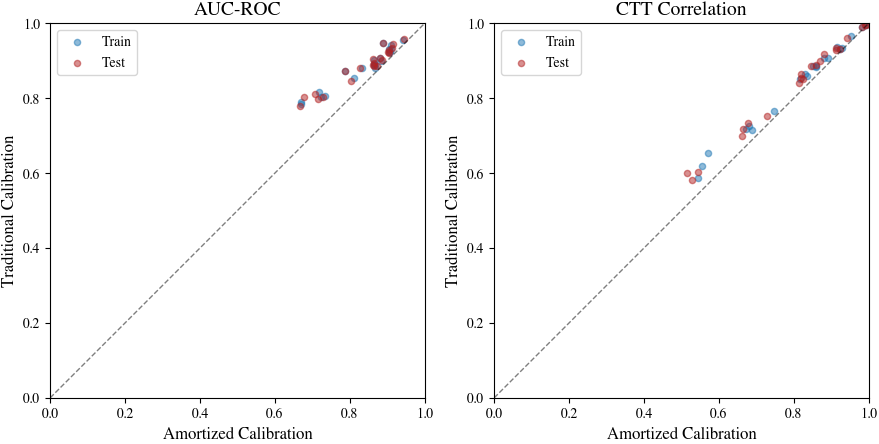

In [18]:
# ===================================================================
# == Create Figure 4 Style Visualization
# ===================================================================
print("\nCreating Figure 4 style visualization...")

with plt.rc_context(bundles.icml2024(usetex=False, family="serif")):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))
    
    # Define colors for train/test
    train_color = 'C0'
    test_color = 'firebrick'
    
    # =============================================
    # Left plot: AUC-ROC comparison
    # =============================================
    ax1.scatter(results_clean['nn_train_auc'], results_clean['mirt_train_auc'], 
                color=train_color, alpha=0.5, s=20, label='Train')
    ax1.scatter(results_clean['nn_test_auc'], results_clean['mirt_test_auc'], 
                color=test_color, alpha=0.5, s=20, label='Test')
    
    # Add diagonal line (perfect agreement)
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
    
    ax1.set_xlabel('Amortized Calibration', fontsize=12)
    ax1.set_ylabel('Traditional Calibration', fontsize=12)
    ax1.set_title('AUC-ROC', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.set_aspect('equal', adjustable='box')
    ax1.tick_params(axis='both', labelsize=10)
    
    # Set limits to ensure square plot
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # =============================================
    # Right plot: CTT Correlation comparison  
    # =============================================
    ax2.scatter(results_clean['nn_train_ctt'], results_clean['mirt_train_ctt'], 
                color=train_color, alpha=0.5, s=20, label='Train')
    ax2.scatter(results_clean['nn_test_ctt'], results_clean['mirt_test_ctt'], 
                color=test_color, alpha=0.5, s=20, label='Test')
    
    # Add diagonal line (perfect agreement)
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
    
    ax2.set_xlabel('Amortized Calibration', fontsize=12)
    ax2.set_ylabel('Traditional Calibration', fontsize=12)
    ax2.set_title('CTT Correlation', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.set_aspect('equal', adjustable='box')
    ax2.tick_params(axis='both', labelsize=10)
    
    # Set limits to ensure square plot
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Make room for the title
    
    # Save the figure
    plt.savefig('../result/comparison_calibration.pdf', bbox_inches='tight')
    plt.show()
